# Active Matter - DS Study

A matéria ativa é uma área da física, derivada da mecânica estatística de Não-Equilíbrio e da *soft matter*. <br>
Estuda, em resumo, sistemas compostos por unidades que, individualmente, consomem energia para gerar movimento. <br>


## Dynamic - ABP (Active Brownian Particle)

Dentre alguns tipos de Matérias ativas, temos as **Partículas Brownianas Ativas**.

Pode-se definir uma ABP como uma partícula que possui velocidade de autopropulsão constante $v_0$ ao longo de <br> um eixo de orientação $\hat{n}$, cuja direção tende a mudar, devido à difusão rotacional, estocasticamente.

Para o caso em duas dimensões (2D), o movimento será descrito pela **Dinâmica de Langevin**: <br>


$$
  \mathbf{\dot{r}}(t) = v_{0}\mathbf{\hat{n}}(\phi) + \sqrt{2D_{t}}\xi_{t}(t)
$$  
<br>
$$
\dot{\phi}(t) = \sqrt{2D_r}\xi_{r}(t)
$$

Onde:

*   $\mathbf{r}(t)$ é a posição da partícula.
*   $\hat{\mathbf{n}}(\phi) = (\cos\phi, \sin\phi)$ é o vetor unitário de orientação.
*   $D_t$ e $D_r$ são os coeficientes de difusão translacional e rotacional, respectivamente.
*   $\boldsymbol{\xi}_t$ e $\xi_r$ representam o ruído branco Gaussiano (flutuações térmicas) com média zero e correlação delta.
*   $v_0$ é a velocidade inicial de autopropulsão

In [1]:
import numpy as np

In [2]:
num_particles = 1
v0 = 2.0
Dr = 0.5
Dt = 0.1

Usando o método de Euler-Maruyama para aproximações de primeira ordem, temos:

$$
\phi_{i+1} = \phi_{i} + 2D_r \Delta t\cdot \xi_{\phi}
$$ <br>
$$
x_{i+1} = x_{i} + 2D_t \Delta t\cdot \xi_{x}
$$ <br>
$$
y_{i+1} = y_{i} + 2D_t \Delta t\cdot \xi_{y}
$$ <br>

In [3]:
def generate_dynamic_abp(*, particles: int, velocity: float,
                      rotational_D: float, translational_D: float, 
                      total_time: float = 50., step_dt: float = 0.001) -> dict:
    """
    Simula o comportamento de partículas Brownianas Ativas via Euler-Maruyama.
    """
    total_steps = int(total_time / step_dt)

    x = np.zeros((total_steps, particles))
    y = np.zeros((total_steps, particles))
    phi = np.zeros((total_steps, particles))
    
    time_array = np.arange(total_steps) * step_dt

    # Condições iniciais
    phi[0] = np.random.uniform(0, 2 * np.pi, particles)

    sqrt_trans = np.sqrt(2 * translational_D * step_dt)
    sqrt_rot = np.sqrt(2 * rotational_D * step_dt)

    for t in range(total_steps - 1):
        noise_phi = np.random.normal(0, sqrt_rot, particles)
        noise_x = np.random.normal(0, sqrt_trans, particles)
        noise_y = np.random.normal(0, sqrt_trans, particles)

        phi[t + 1] = phi[t] + noise_phi
        x[t + 1] = x[t] + (velocity * np.cos(phi[t]) * step_dt) + noise_x
        y[t + 1] = y[t] + (velocity * np.sin(phi[t]) * step_dt) + noise_y

    return {
        "x": x, "y": y, "phi": phi,
        "time": time_array,
        "parameters": {
            "v0": velocity,
            "Dr": rotational_D,
            "Dt": translational_D,
            "dt": step_dt,
            "num_particles": particles,
            "steps": total_steps
        }
    }

In [4]:
import matplotlib.pyplot as plt

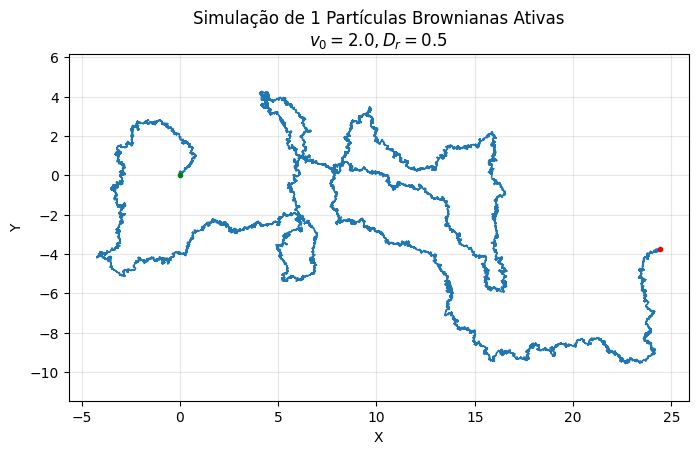

In [5]:
simulacao = generate_dynamic_abp(velocity=v0, particles=num_particles,
                             rotational_D=Dr, translational_D=Dt)
x = simulacao['x']
y = simulacao['y']

plt.figure(figsize=(8,4.5), dpi=100)
plt.plot(x, y, lw=1)
plt.plot(x[0][:], y[0][:], 'go', ms=3)
plt.plot(x[-1][:], y[-1][:], 'ro', ms=3)


plt.title(f"Simulação de {simulacao['parameters']['num_particles']} Partículas Brownianas Ativas\n$v_0={simulacao['parameters']['v0']}, D_r={simulacao['parameters']['Dr']}$")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

## Trajectory analysis

O método escolhido é o Delocamento Quadrático Médio - Mean Squared Displacement (MSD). <br>
O MSD quantifica quanto uma partícula se moveu em relação à sua posição inicial ao longo do tempo.

Na mecânica estátistica, geralmente lidamos com médias de *ensembles* (média sobre muitas "cópias" do sistema.)<br>
Caso tivessemos $N = 1000$ partículas, calcularia-se, discretamente, o MSD:

$$
\left < \mathbf{r^{2}}(t)  \right > = \frac{1}{N} \sum^{N}_{i=1} \left[\mathbf{r}_{i}(t) - \mathbf{r}_{i}(0) \right]^{2}
$$

Já com $N = 1$, essa média seria extremamente ruidosa e dependente das condições iniciais.<br>
Para contornar, utilizamos o Time Avareged MSD (TAMSD) que pode servir mais genericamente, por sua robustez:

$$\text{TAMSD}(n \cdot dt) = \frac{1}{M(N_{steps} - n)} \sum_{j=i}^{M} \sum_{i=0}^{N_{steps} - n - 1}  [\mathbf{r}(t_{i+n}) - \mathbf{r}(t_i)]^2$$